In [155]:
import pandas as pd
import numpy as np

In [156]:
#Load data
df=pd.read_csv(r"C:\Users\Tejaswini Pusala\Downloads\Vcube\Machine Learning\ML Project\Loan.csv")
df

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,01-01-2018,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,02-01-2018,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,03-01-2018,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,04-01-2018,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,05-01-2018,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179141,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,29-09-2072,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,30-09-2072,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,01-10-2072,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,02-10-2072,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


In [157]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

(20000, 36)

In [158]:
#checking null values
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [159]:
print(df.columns)

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')


In [160]:
# Convert to datetime
df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"], dayfirst=True)

# Extract features
df["Year"] = df["ApplicationDate"].dt.year
df["Month"] = df["ApplicationDate"].dt.month
df["Day"] = df["ApplicationDate"].dt.day

# Remove original date column
df.drop("ApplicationDate", axis=1, inplace=True)

In [161]:
df

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,Year,Month,Day
0,45,39948,617,Employed,Master,22,13152,48,Married,2,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,2018,1,1
1,38,39709,628,Employed,Associate,15,26045,48,Single,1,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,2018,1,2
2,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,2018,1,3
3,58,69084,545,Employed,High School,34,37898,96,Single,1,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,2018,1,4
4,37,103264,594,Employed,Associate,17,9184,36,Married,1,...,227019,0.197184,0.175990,330.179141,0.070210,1,36.0,2018,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,44,30180,587,Employed,High School,19,24521,36,Married,3,...,55327,0.216021,0.195574,905.767712,0.627741,0,55.0,2072,9,29
19996,56,49246,567,Employed,Associate,33,25818,36,Married,5,...,64002,0.227318,0.199168,958.395633,0.334418,0,54.0,2072,9,30
19997,44,48958,645,Employed,Bachelor,20,37033,72,Married,3,...,103663,0.229533,0.226766,945.427454,0.357227,0,45.0,2072,10,1
19998,60,41025,560,Employed,High School,36,14760,72,Married,3,...,10600,0.249760,0.264873,411.168284,0.408678,0,59.0,2072,10,2


In [162]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(num_cols)

Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='object')


In [163]:
#Target Variable Analysis
print(df["LoanApproved"].value_counts())

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


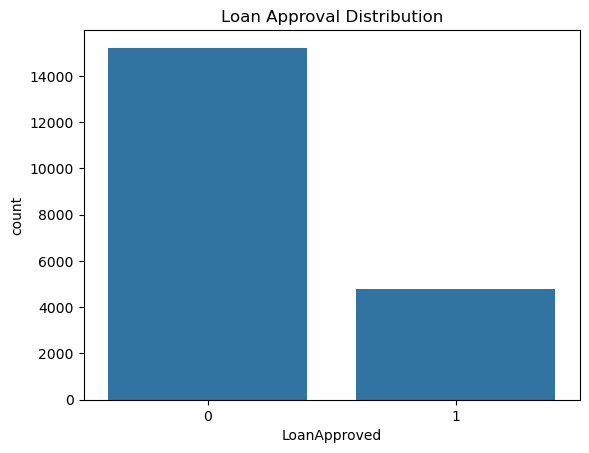

In [164]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="LoanApproved", data=df)
plt.title("Loan Approval Distribution")
plt.show()

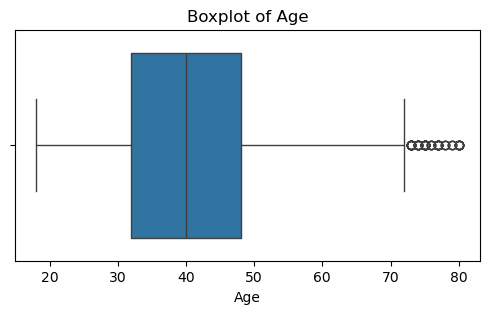

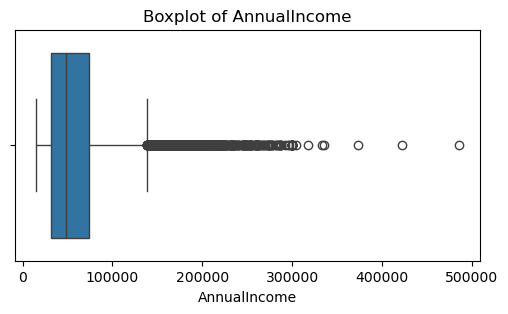

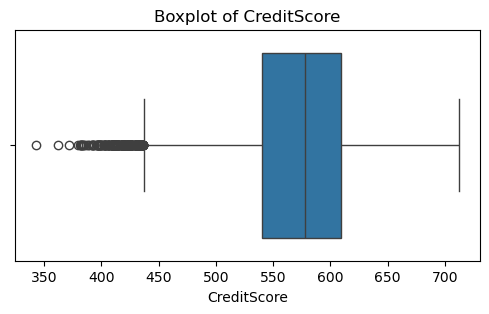

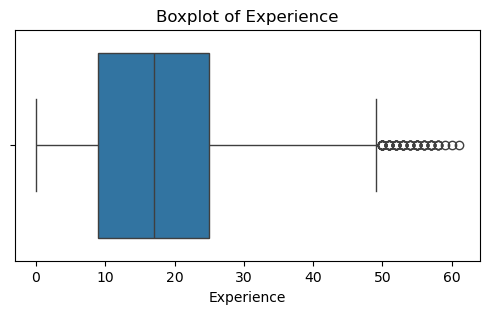

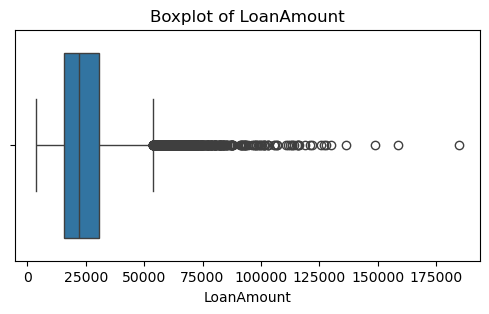

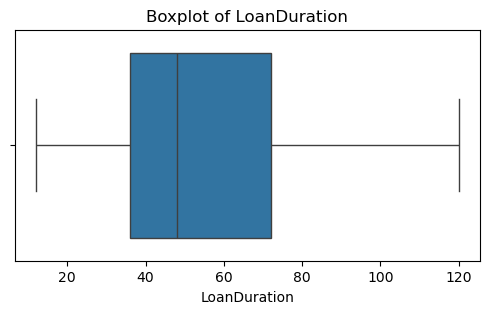

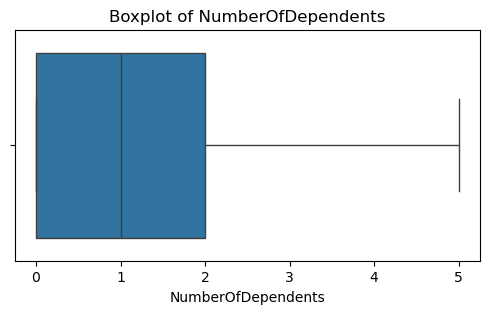

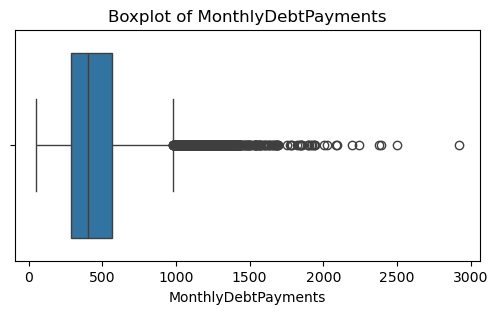

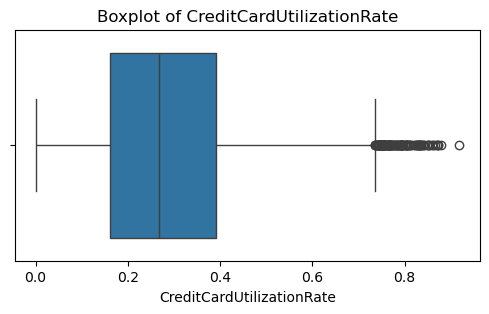

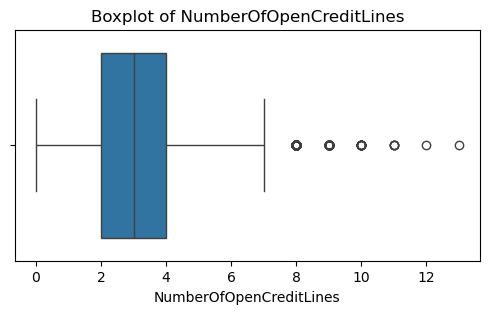

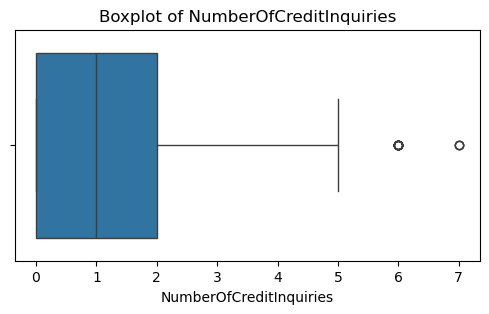

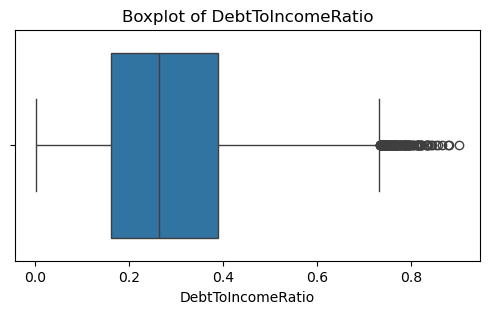

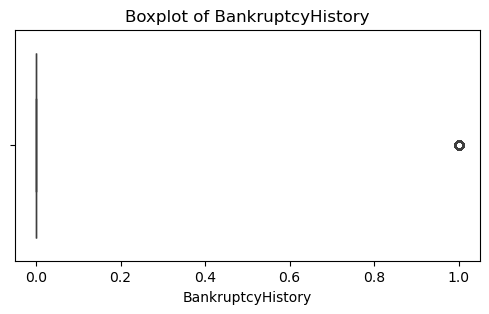

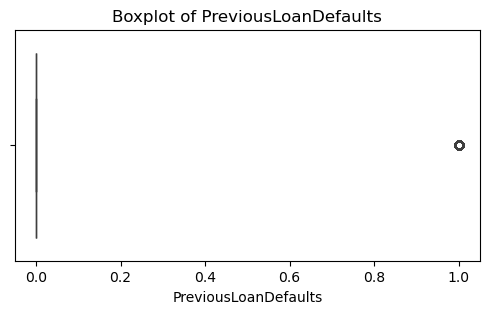

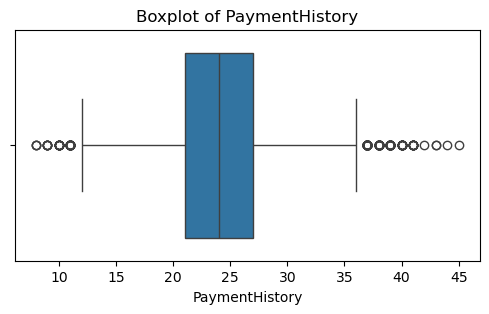

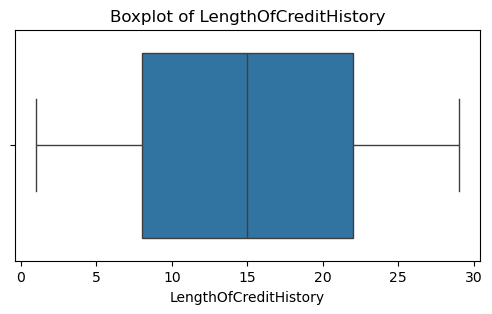

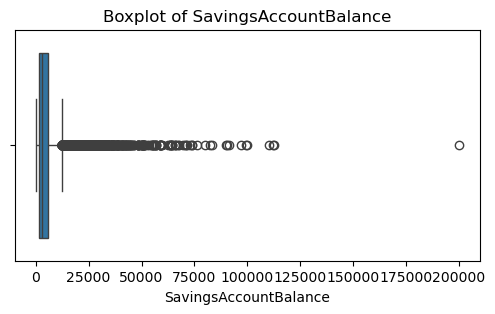

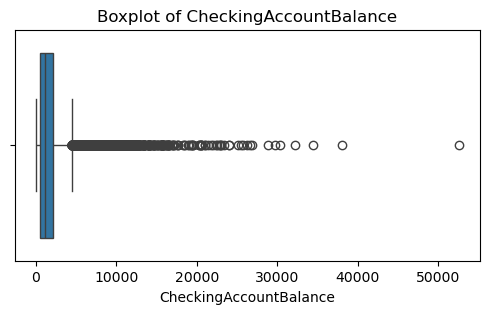

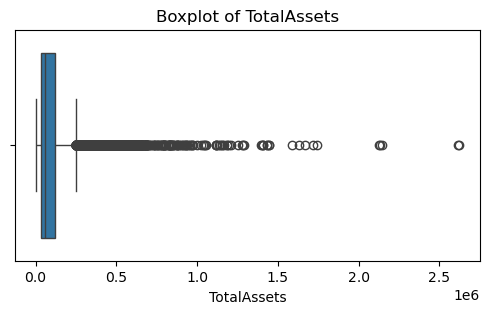

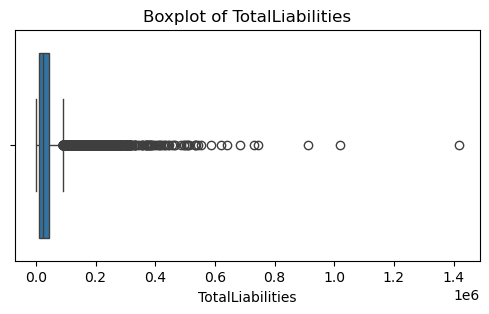

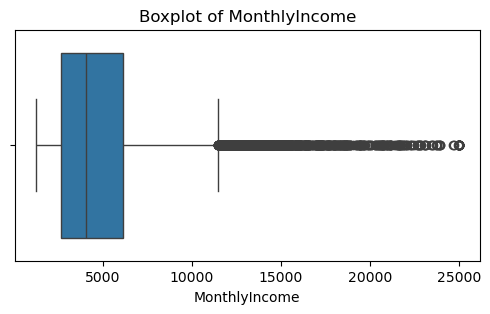

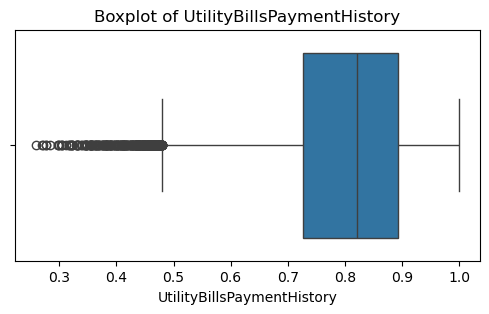

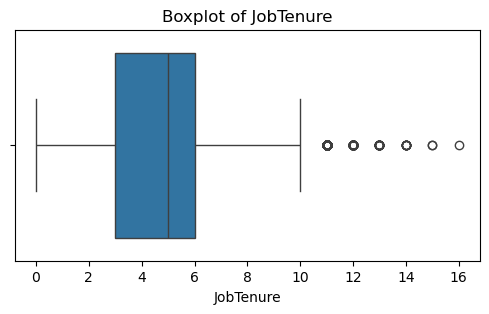

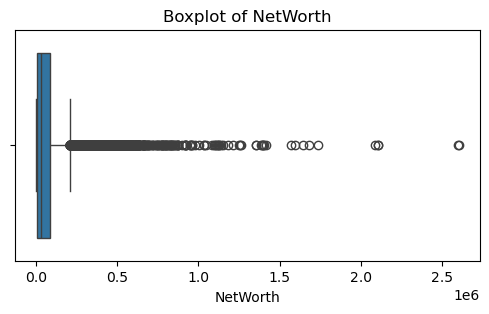

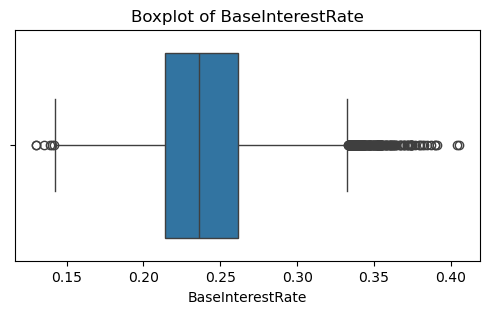

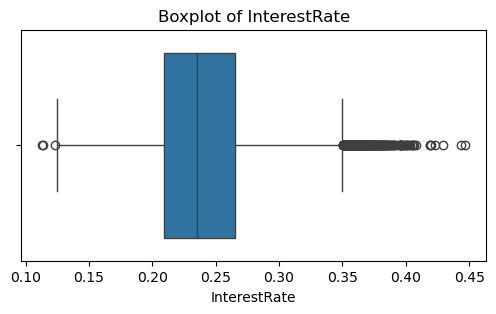

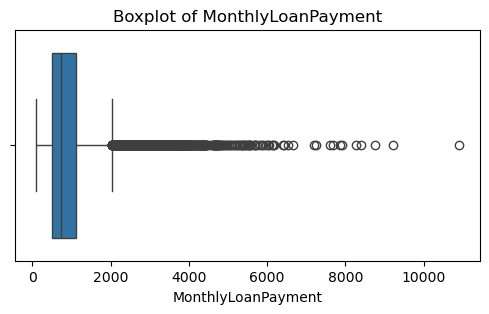

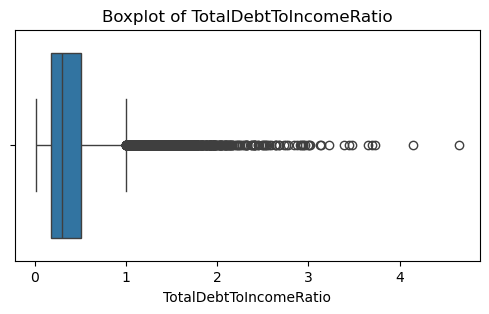

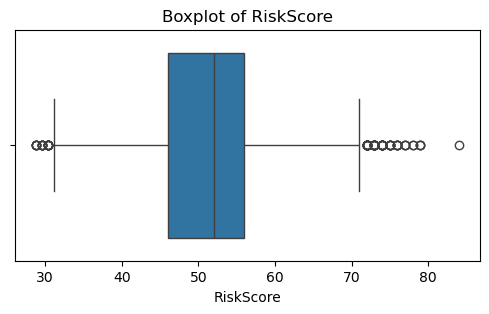

In [165]:
#Outlier analysis using boxplot

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=X[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [166]:
#Count Outliers Using IQR
for col in num_cols:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower) | (X[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Age: 64 outliers
AnnualIncome: 947 outliers
CreditScore: 242 outliers
Experience: 75 outliers
LoanAmount: 746 outliers
LoanDuration: 0 outliers
NumberOfDependents: 0 outliers
MonthlyDebtPayments: 744 outliers
CreditCardUtilizationRate: 130 outliers
NumberOfOpenCreditLines: 249 outliers
NumberOfCreditInquiries: 16 outliers
DebtToIncomeRatio: 143 outliers
BankruptcyHistory: 1048 outliers
PreviousLoanDefaults: 2001 outliers
PaymentHistory: 241 outliers
LengthOfCreditHistory: 0 outliers
SavingsAccountBalance: 1592 outliers
CheckingAccountBalance: 1522 outliers
TotalAssets: 1442 outliers
TotalLiabilities: 1533 outliers
MonthlyIncome: 925 outliers
UtilityBillsPaymentHistory: 294 outliers
JobTenure: 251 outliers
NetWorth: 1564 outliers
BaseInterestRate: 219 outliers
InterestRate: 222 outliers
MonthlyLoanPayment: 1089 outliers
TotalDebtToIncomeRatio: 1152 outliers
RiskScore: 94 outliers


In [167]:
#Treat Outliers (Recommended: Capping)
X_cap = X.copy()

for col in num_cols:

    Q1 = X_cap[col].quantile(0.25)
    Q3 = X_cap[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_cap[col] = X_cap[col].clip(lower, upper)


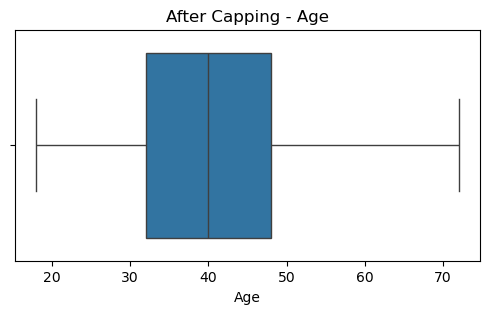

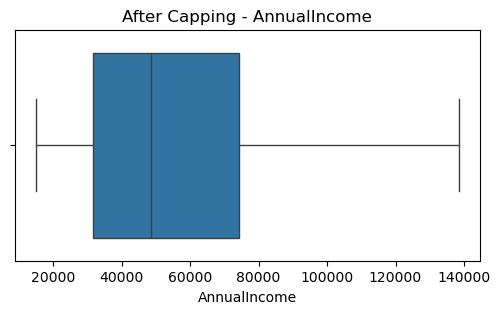

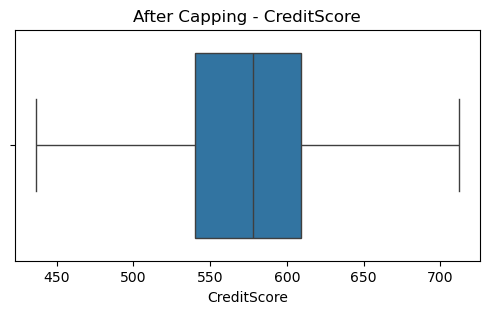

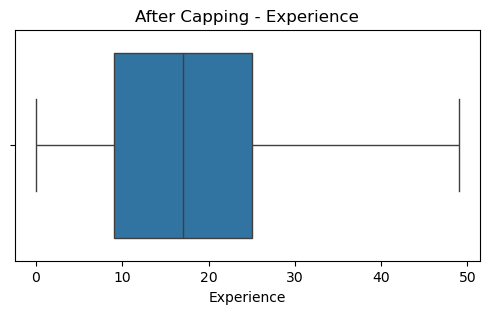

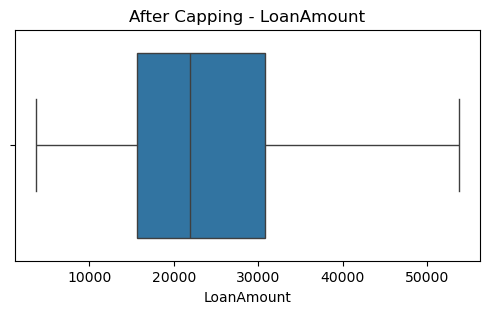

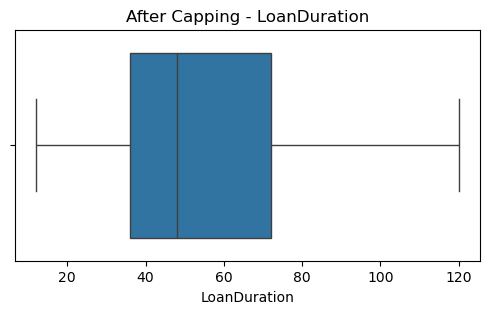

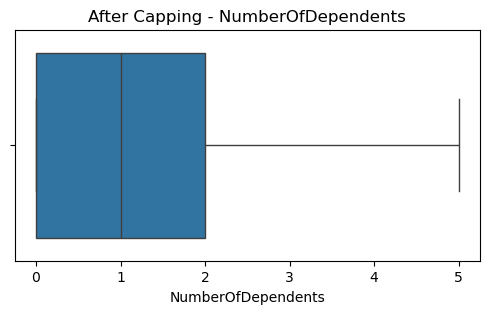

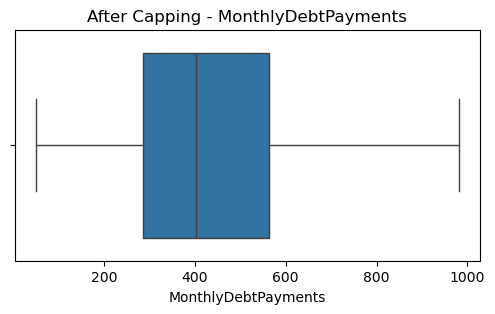

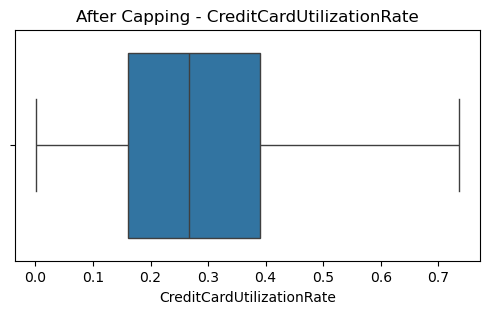

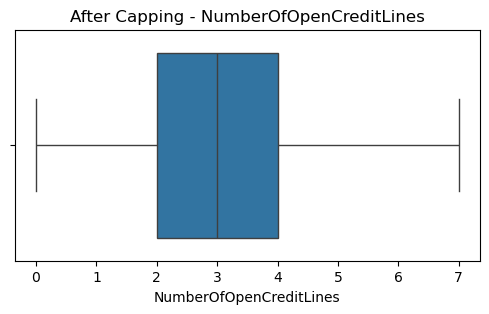

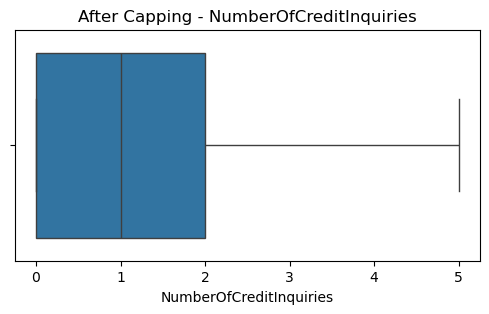

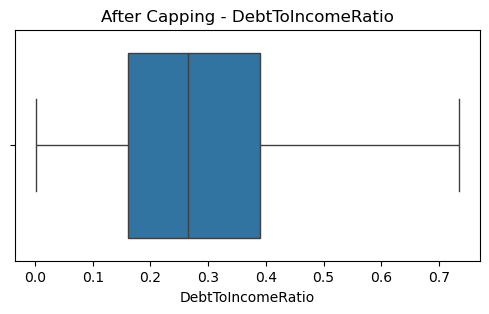

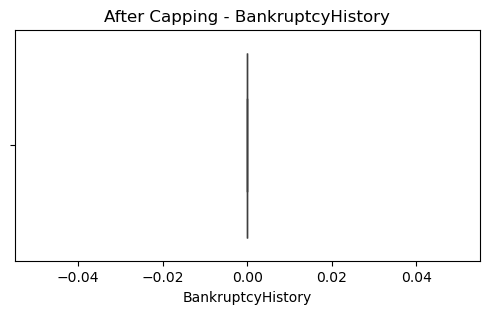

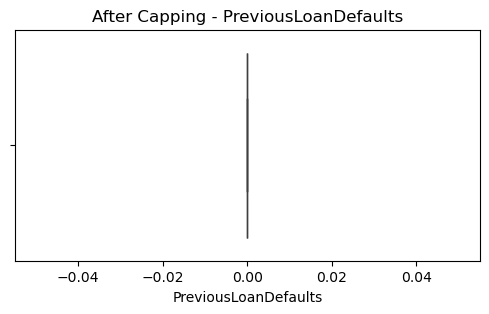

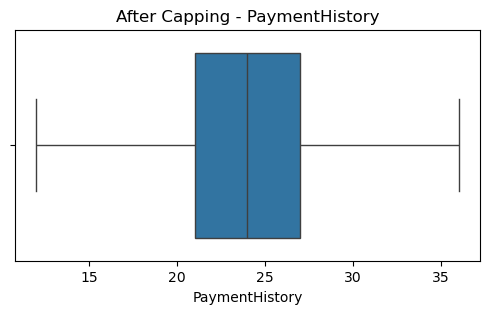

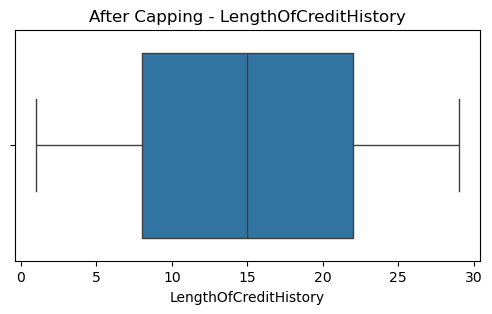

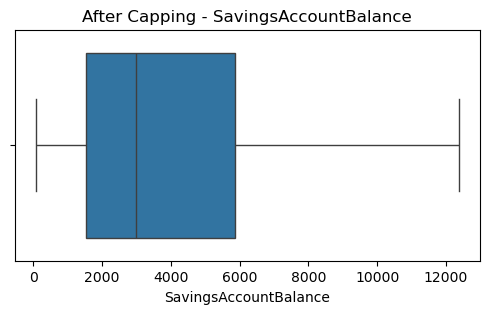

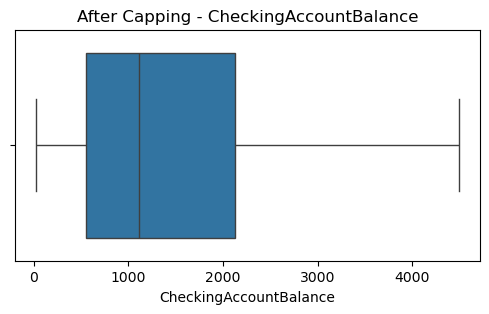

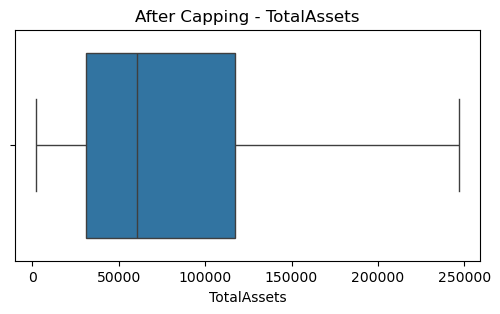

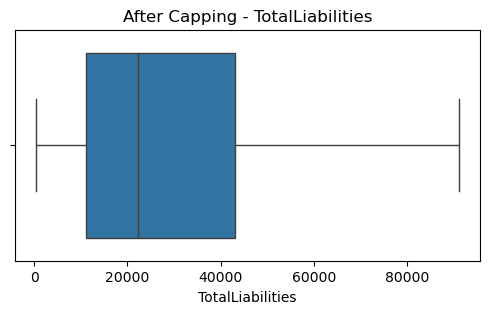

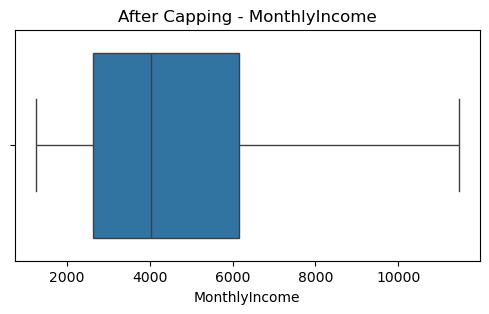

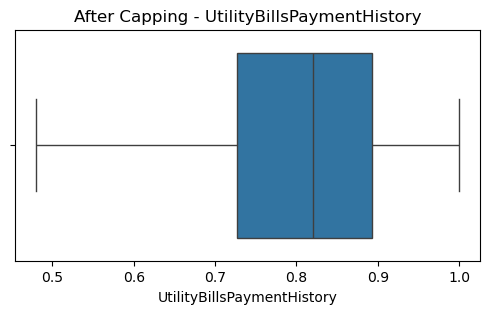

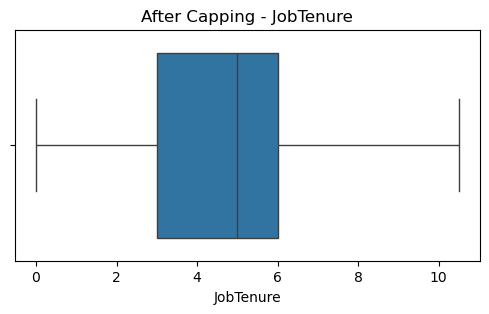

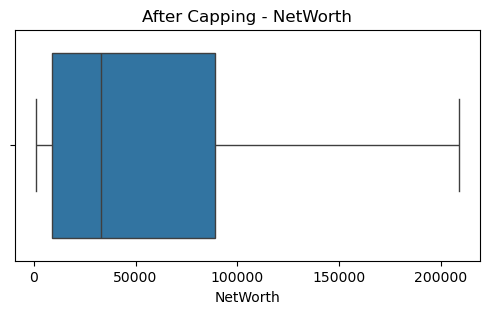

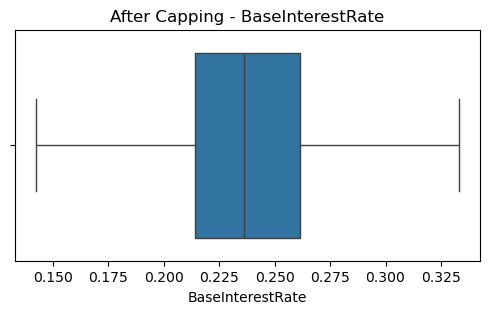

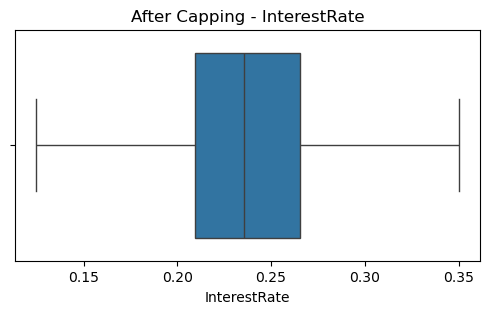

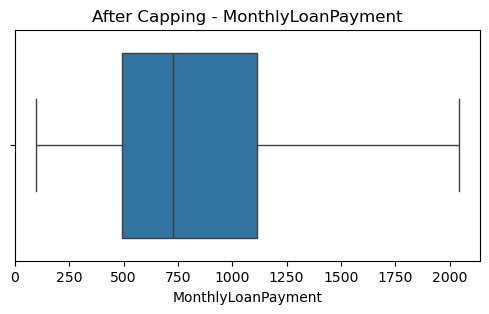

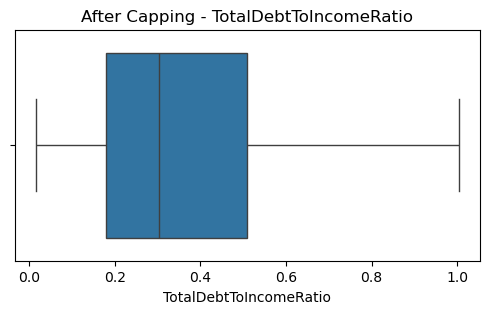

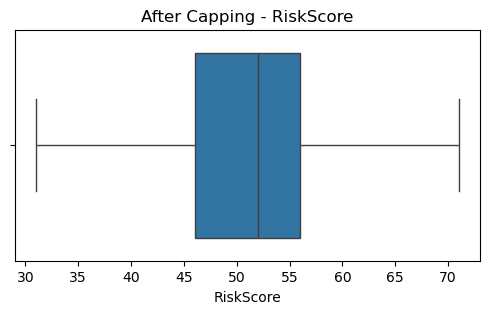

In [168]:
for col in num_cols:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=X_cap[col])
    plt.title(f"After Capping - {col}")
    plt.show()

In [169]:
#Feature scaling
print(X.select_dtypes(include=['object']).columns)
print(X.shape)

Index(['ApplicationDate'], dtype='object')
(20000, 46)


In [48]:
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore', 'Year', 'Month', 'Day'],
      dtype='object')

In [49]:
print(X.select_dtypes(include=['object']).columns)
print(X.dtypes)

Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object')
Age                             int64
AnnualIncome                    int64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory               int64
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance           int64
CheckingAccountBalance          in

In [170]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of X columns:", len(X.columns))

X shape: (20000, 46)
X_train shape: (16000, 20044)
X_test shape: (4000, 20044)
Number of X columns: 46


In [171]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


In [172]:
print(X.shape)
print(X.dtypes[X.dtypes == "object"])

(20000, 46)
ApplicationDate    object
dtype: object


In [173]:
# Create features and target
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

# One-hot encode categorical columns
categorical_cols = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [174]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [175]:
#Train LR
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [176]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [177]:
y_pred = rf.predict(X_test)

In [178]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [179]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [180]:
#Accuracy
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.98925
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.98      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000



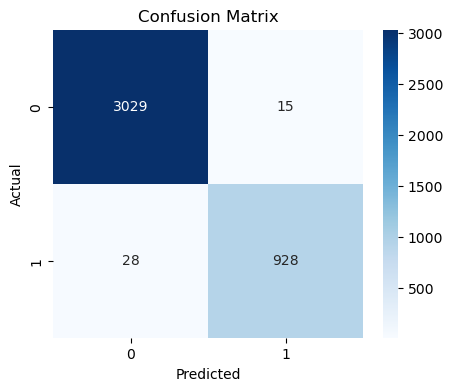

In [181]:
#Plot the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [182]:
#Calculate ROC-AUC Score #LR
from sklearn.metrics import roc_auc_score

prob = lr.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, prob)

print("ROC AUC:", roc)

ROC AUC: 0.5883705650459921


In [183]:
#RF
from sklearn.metrics import roc_auc_score

prob = rf.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, prob)

print("ROC AUC:", roc)

ROC AUC: 0.9992185738870347


In [184]:
#Comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        0.5883,
        0.9992
    ]
})
comparison

,Model,ROC-AUC
0,Logistic Regression,0.5883
1,Random Forest,0.9992


In [185]:
print(df.shape)

(20000, 38)


In [186]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save feature names
with open("model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!
